# 지도학습 - 회귀 (통합 데이터: 시설물 + 구조 위험)

## 1) 라이브러리 및 데이터 불러오기

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, recall_score, f1_score, classification_report
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

plt.rcParams['axes.unicode_minus'] = False
font_list = [f.name for f in fm.fontManager.ttflist
             if any(k in f.name for k in ['Nanum', 'Gothic', 'Malgun'])]
plt.rcParams['font.family'] = font_list[0] if font_list else 'DejaVu Sans' 

In [14]:
df_all = pd.read_csv('./data/seongnam_train.csv', encoding='utf-8-sig')

print(f"전체 데이터: {df_all.shape[0]}행 x {df_all.shape[1]}열")
print(f"\n컬럼: {df_all.columns.tolist()}")

전체 데이터: 110행 x 15열

컬럼: ['시설물명', '위도', '경도', '도로안전표지', '도로적색표면', '무단횡단방지펜스', '무인교통단속카메라', '보호구역표지판', '생활안전CCTV', '신호등', '옐로카펫', '횡단보도', '어린이 비율(%)', '발생건수', 'structure_risk']


In [15]:
LABEL = '발생건수'
DROP  = ['시설물명', '위도', '경도', 'structure_risk', LABEL]


STEP 1 | 데이터 기본 탐색 (seongnam_train.csv)
데이터 크기: 110행 x 15열

결측치:
없음

기술통계:
            위도       경도   도로안전표지   도로적색표면  무단횡단방지펜스  무인교통단속카메라  보호구역표지판  생활안전CCTV      신호등     옐로카펫     횡단보도  어린이 비율(%)     발생건수  structure_risk
count  110.000  110.000  110.000  110.000   110.000    110.000  110.000   110.000  110.000  110.000  110.000    110.000  110.000         110.000
mean    37.411  127.133    0.056    0.023    -0.042     -0.063   -0.003     0.092    0.006    0.008    0.060     -0.036    0.164           0.000
std      0.037    0.023    1.002    1.005     1.026      1.036    1.057     1.014    1.033    1.071    0.992      1.025    0.684           1.005
min     37.338  127.069   -1.481   -1.622    -1.698     -1.745   -4.300    -2.908   -1.552   -1.457   -1.543     -1.646    0.000          -1.909
25%     37.375  127.118   -0.664   -0.603    -0.868     -0.500   -0.482    -0.542   -0.666   -1.457   -0.713     -0.883    0.000          -0.796
50%     37.410  127.133    0.152   -0.263    -0.239    

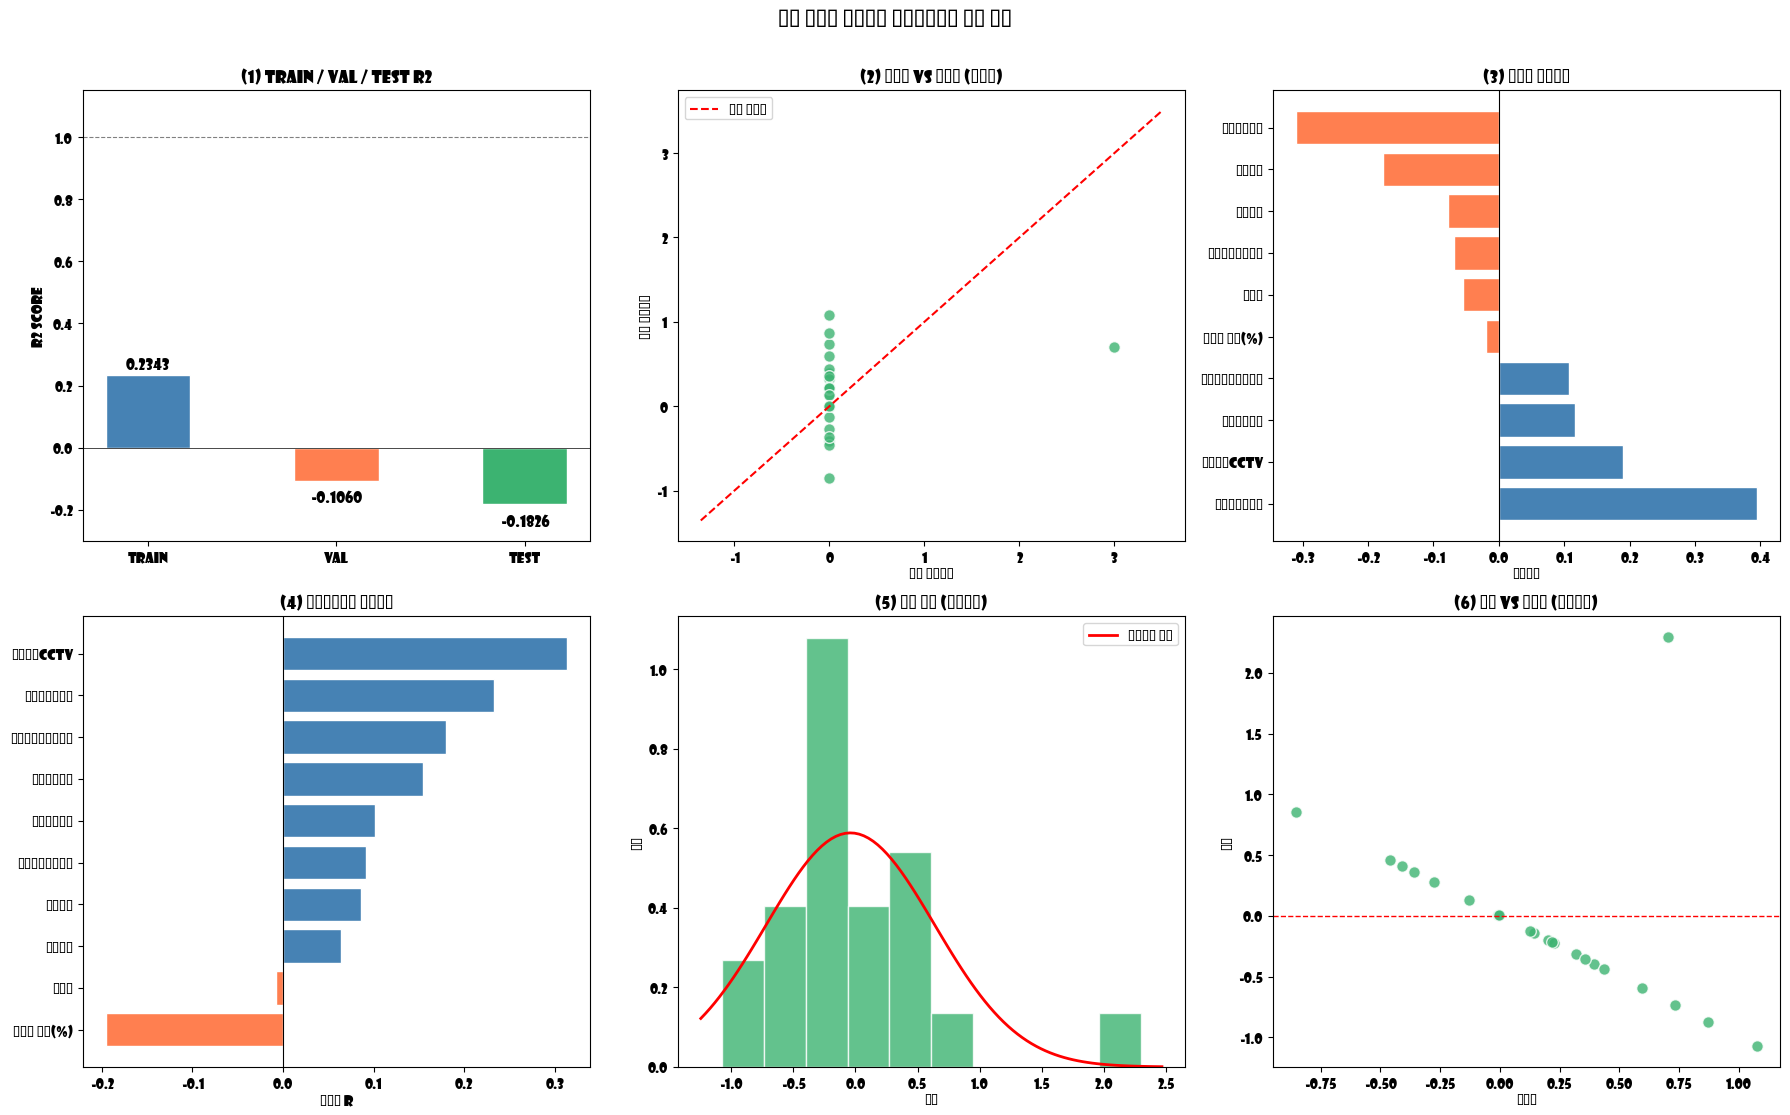


시각화 저장 완료: regression_integrated_result.png


In [16]:
df = df_all.copy()

# ═══════════════════════════════════════════════════════════════════
# STEP 1 ── 데이터 기본 탐색
# ═══════════════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 1 | 데이터 기본 탐색 (seongnam_train.csv)")
print("=" * 60)
print(f"데이터 크기: {df.shape[0]}행 x {df.shape[1]}열")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"\n결측치:\n{missing.to_string() if len(missing) > 0 else '없음'}")
print(f"\n기술통계:\n{df.describe().round(3).to_string()}")

X_raw    = df.drop(columns=DROP)
y        = df[LABEL]
features = X_raw.columns.tolist()
print(f"\n사용 피처 ({len(features)}개): {features}")
print(f"레이블 분포 - min:{y.min():.1f}  max:{y.max():.1f}  mean:{y.mean():.4f}  std:{y.std():.4f}")
print(f"\n발생건수 값 분포:\n{y.value_counts().sort_index().to_string()}")

# ═══════════════════════════════════════════════════════════════════
# STEP 2 ── 상관관계 분석
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 2 | 상관관계 분석 (피어슨 r)")
print("=" * 60)

corr_with_label = X_raw.apply(lambda col: col.corr(y))
corr_df = corr_with_label.sort_values(ascending=False).to_frame(name='r')
corr_df['|r|'] = corr_df['r'].abs()
print(corr_df.round(4).to_string())

# ═══════════════════════════════════════════════════════════════════
# STEP 3 ── 다중공선성 검사 (VIF)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 3 | 다중공선성 검사 (VIF)")
print("=" * 60)

scaler_vif   = StandardScaler()
X_scaled_vif = scaler_vif.fit_transform(X_raw)

vif_data = pd.DataFrame({
    'Feature': features,
    'VIF': [variance_inflation_factor(X_scaled_vif, i)
            for i in range(X_scaled_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.round(2).to_string(index=False))
high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
if high_vif:
    print(f"\nVIF > 10 (다중공선성 의심): {high_vif}")
else:
    print("\n심각한 다중공선성 없음 (모두 VIF <= 10)")

# ═══════════════════════════════════════════════════════════════════
# STEP 4 ── 데이터 분할 및 모델 학습
# 전체 → 80% trainval / 20% test
# trainval → 80% train / 20% val
# 최종 비율: train ≈ 64% / val ≈ 16% / test ≈ 20%
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 4 | 모델 학습 (train 64% / val 16% / test 20%)")
print("=" * 60)

# 1차 분할: 전체 → trainval 80% / test 20%
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# 2차 분할: trainval → train 80% / val 20%
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42
)

print(f"전체: {len(X_raw)}  →  학습: {len(X_tr)}  검증: {len(X_val)}  테스트: {len(X_test)}")

# scaler는 학습셋에서만 fit (검증/테스트는 transform만)
scaler  = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_val_s  = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_tr_s, y_tr)

y_pred_tr   = model.predict(X_tr_s)
y_pred_val  = model.predict(X_val_s)
y_pred_test = model.predict(X_test_s)

print(f"절편 (intercept): {model.intercept_:.4f}")

coef_df = pd.DataFrame({
    'Feature': features,
    'Coef': model.coef_
}).sort_values('Coef', ascending=False)
print(f"\n회귀계수:\n{coef_df.round(4).to_string(index=False)}")

# ═══════════════════════════════════════════════════════════════════
# STEP 5 ── 회귀 지표 (학습 / 검증 / 테스트)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 5 | 회귀 지표")
print("=" * 60)

tr_r2    = r2_score(y_tr,   y_pred_tr)
val_r2   = r2_score(y_val,  y_pred_val)
test_r2  = r2_score(y_test, y_pred_test)
tr_mae   = mean_absolute_error(y_tr,   y_pred_tr)
val_mae  = mean_absolute_error(y_val,  y_pred_val)
test_mae = mean_absolute_error(y_test, y_pred_test)
tr_rmse   = np.sqrt(mean_squared_error(y_tr,   y_pred_tr))
val_rmse  = np.sqrt(mean_squared_error(y_val,  y_pred_val))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

metrics_all = pd.DataFrame({
    'Metric': ['R2', 'MAE', 'RMSE'],
    'Train':  [tr_r2,   tr_mae,   tr_rmse],
    'Val':    [val_r2,  val_mae,  val_rmse],
    'Test':   [test_r2, test_mae, test_rmse],
})
print(metrics_all.round(4).to_string(index=False))
print(f"\n과적합 지수 (Train R2 - Val R2): {(tr_r2 - val_r2):.4f}")

# ═══════════════════════════════════════════════════════════════════
# STEP 6 ── 분류 지표 (이진 이산화: 없음/있음)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 6 | 분류 지표 (이진: 없음·있음)")
print("=" * 60)

BINS        = [float('-inf'), 0.5, float('inf')]
LABELS_CLS  = [0, 1]
CLASS_NAMES = ['없음(0건)', '있음(1건~)']

def to_cls(s):
    return pd.cut(pd.Series(s).reset_index(drop=True),
                  bins=BINS, labels=LABELS_CLS).astype(int).values

y_val_cls   = to_cls(y_val);  y_pred_val_cls  = to_cls(y_pred_val)
y_test_cls  = to_cls(y_test); y_pred_test_cls = to_cls(y_pred_test)

print("[검증셋]")
print(f"  Accuracy : {accuracy_score(y_val_cls, y_pred_val_cls):.4f}")
print(f"  Recall   : {recall_score(y_val_cls, y_pred_val_cls, average='macro', zero_division=0):.4f}")
print(f"  F1-Score : {f1_score(y_val_cls, y_pred_val_cls, average='macro', zero_division=0):.4f}")
print(f"\n{classification_report(y_val_cls, y_pred_val_cls, target_names=CLASS_NAMES, zero_division=0)}")

print("[테스트셋]")
print(f"  Accuracy : {accuracy_score(y_test_cls, y_pred_test_cls):.4f}")
print(f"  Recall   : {recall_score(y_test_cls, y_pred_test_cls, average='macro', zero_division=0):.4f}")
print(f"  F1-Score : {f1_score(y_test_cls, y_pred_test_cls, average='macro', zero_division=0):.4f}")
print(f"\n{classification_report(y_test_cls, y_pred_test_cls, target_names=CLASS_NAMES, zero_division=0)}")

# ═══════════════════════════════════════════════════════════════════
# STEP 7 ── 잔차 분석 (테스트셋)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 7 | 잔차 분석 (테스트셋)")
print("=" * 60)

residuals_val  = y_val.values  - y_pred_val
residuals_test = y_test.values - y_pred_test

stat_v, p_v = stats.shapiro(residuals_val)
stat_t, p_t = stats.shapiro(residuals_test)

print(f"[검증셋] Shapiro-Wilk - W={stat_v:.4f}, p={p_v:.4f}  "
      f"{'만족 (p > 0.05)' if p_v > 0.05 else '불만족 (p <= 0.05)'}")
print(f"  잔차 평균: {residuals_val.mean():.4f}  |  표준편차: {residuals_val.std():.4f}")
print(f"[테스트셋] Shapiro-Wilk - W={stat_t:.4f}, p={p_t:.4f}  "
      f"{'만족 (p > 0.05)' if p_t > 0.05 else '불만족 (p <= 0.05)'}")
print(f"  잔차 평균: {residuals_test.mean():.4f}  |  표준편차: {residuals_test.std():.4f}")

# ═══════════════════════════════════════════════════════════════════
# STEP 8 ── 시각화 (2행 3열)
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('통합 데이터 발생건수 다중선형회귀 분석 결과', fontsize=16, fontweight='bold', y=1.01)

# (1) Train / Val / Test R² 비교
ax = axes[0, 0]
bars = ax.bar(['Train', 'Val', 'Test'], [tr_r2, val_r2, test_r2],
               color=['steelblue', 'coral', 'mediumseagreen'], width=0.45, edgecolor='white')
ax.set_ylim(-0.3, 1.15)
ax.set_ylabel('R2 Score')
ax.set_title('(1) Train / Val / Test R2')
ax.axhline(0.0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
for bar, v in zip(bars, [tr_r2, val_r2, test_r2]):
    ypos = bar.get_height() + 0.02 if bar.get_height() >= 0 else bar.get_height() - 0.07
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

# (2) 실제값 vs 예측값 (테스트셋)
ax = axes[0, 1]
ax.scatter(y_test, y_pred_test, alpha=0.8, color='mediumseagreen', edgecolors='white', s=70)
mn = min(float(y_test.min()), float(y_pred_test.min())) - 0.5
mx = max(float(y_test.max()), float(y_pred_test.max())) + 0.5
ax.plot([mn, mx], [mn, mx], 'r--', label='완벽 예측선')
ax.set_xlabel('실제 발생건수')
ax.set_ylabel('예측 발생건수')
ax.set_title('(2) 실제값 vs 예측값 (테스트)')
ax.legend()

# (3) 피처별 회귀계수
ax = axes[0, 2]
colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coef']]
ax.barh(coef_df['Feature'], coef_df['Coef'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('회귀계수')
ax.set_title('(3) 피처별 회귀계수')

# (4) 상관계수
ax = axes[1, 0]
sorted_corr = corr_df.sort_values('r')
ax.barh(sorted_corr.index, sorted_corr['r'],
        color=['coral' if v < 0 else 'steelblue' for v in sorted_corr['r']],
        edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('피어슨 r')
ax.set_title('(4) 발생건수와의 상관계수')

# (5) 잔차 분포 (테스트셋)
ax = axes[1, 1]
ax.hist(residuals_test, bins=10, color='mediumseagreen', edgecolor='white', density=True, alpha=0.8)
xmin, xmax = ax.get_xlim()
x_range = np.linspace(xmin, xmax, 100)
ax.plot(x_range, stats.norm.pdf(x_range, residuals_test.mean(), residuals_test.std()),
        'r-', linewidth=2, label='정규분포 곡선')
ax.set_xlabel('잔차')
ax.set_ylabel('밀도')
ax.set_title('(5) 잔차 분포 (테스트셋)')
ax.legend()

# (6) 잔차 vs 예측값 (테스트셋)
ax = axes[1, 2]
ax.scatter(y_pred_test, residuals_test, alpha=0.8, color='mediumseagreen', edgecolors='white', s=70)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('예측값')
ax.set_ylabel('잔차')
ax.set_title('(6) 잔차 vs 예측값 (테스트셋)')

plt.tight_layout()
plt.savefig('./data/regression_integrated_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n시각화 저장 완료: regression_integrated_result.png")
